# Ship Mast Damage Detection — Siamese Network with ResNet50

####Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

data_dir = "/content/drive/My Drive/new_ship_mast_dataset"
print("Dataset root:", data_dir)
print("Mast folders found:", len(os.listdir(data_dir)))

Mounted at /content/drive
Dataset root: /content/drive/My Drive/new_ship_mast_dataset
Mast folders found: 37


####Imports

In [2]:
import os
import random
import numpy as np
import pandas as pd
from itertools import combinations

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms
import torchvision.models as models

from PIL import Image, UnidentifiedImageError
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

print("PyTorch version :", torch.__version__)
print("Device          :", "cuda" if torch.cuda.is_available() else "cpu")

PyTorch version : 2.10.0+cu128
Device          : cuda


#### Creatiing the pairs

Within each *mast_xxx* folder, images whose filename starts with *damage* are **damaged** and all others are **good**.

good–good pairs → label 0 (similar)

good–damaged pairs → label 1 (dissimilar)

In [4]:
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".webp"}

pairs = []

mast_folders = sorted([
    f for f in os.listdir(data_dir)
    if os.path.isdir(os.path.join(data_dir, f))
])

print(f"Found {len(mast_folders)} mast folders")

for mast in mast_folders:
    mast_path = os.path.join(data_dir, mast)

    all_images = [
        f for f in os.listdir(mast_path)
        if os.path.splitext(f)[1].lower() in IMAGE_EXTS
    ]

    # Split by name prefix
    damaged = sorted([f for f in all_images if f.lower().startswith("damage")])
    good    = sorted([f for f in all_images if not f.lower().startswith("damage")])

    # good–good pairs (label 0)
    for img1, img2 in combinations(good, 2):
        pairs.append([
            os.path.join(mast, img1),
            os.path.join(mast, img2),
            0
        ])

    # good–damaged pairs (label 1)
    for g_img in good:
        for d_img in damaged:
            pairs.append([
                os.path.join(mast, g_img),
                os.path.join(mast, d_img),
                1
            ])

df = pd.DataFrame(pairs, columns=["image1", "image2", "label"])

print(f"\nTotal pairs      : {len(df)}")
print(f"  Good–Good (0)  : {(df['label']==0).sum()}")
print(f"  Good–Damaged(1): {(df['label']==1).sum()}")
df.sample(10)

Found 37 mast folders

Total pairs      : 792
  Good–Good (0)  : 353
  Good–Damaged(1): 439


,image1,image2,label
591,mast_029/good_cn_01.jpg,mast_029/good_i2i_02.jpg,0
94,mast_005/good_cn_01.jpg,mast_005/good_cn_02.jpg,0
385,mast_018/good_cn_01.jpg,mast_018/damaged_i2i_01.jpg,1
488,mast_022/good_cn_03 (1).jpg,mast_022/damaged_i2i_03.jpg,1
260,mast_011/good.jpg,mast_011/good_i2i_01.jpg,0
447,mast_021/good_i2i_01.jpg,mast_021/damaged_cn_02.jpg,1
263,mast_011/good_cn_01.jpg,mast_011/good_i2i_01.jpg,0
277,mast_011/good_i2i_02.jpg,mast_011/damaged_i2i_03.jpg,1
672,mast_032/good_i2i_01.jpg,mast_032/original.jpg,0
544,mast_025/good_i2i_02.jpg,mast_025/original.jpg,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 792 entries, 0 to 791
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   image1  792 non-null    object
 1   image2  792 non-null    object
 2   label   792 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 18.7+ KB


In [27]:
df['label'].value_counts()

,count
label,
1,439
0,353


### sample pairs viisaulization

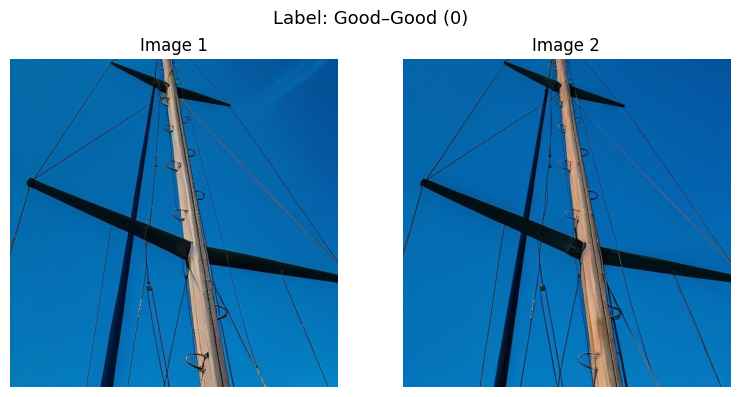

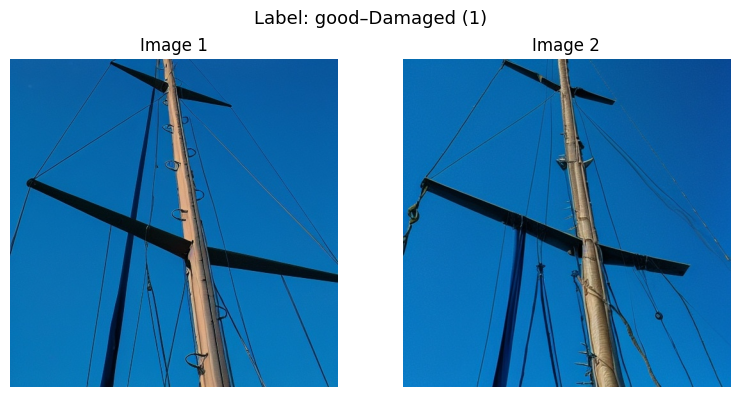

In [30]:
sample_indices = [
    df[df['label'] == 0].index[50],
    df[df['label'] == 1].index[100],
]

for idx in sample_indices:
    row = df.iloc[idx]
    img1 = Image.open(os.path.join(data_dir, row['image1'])).convert('RGB')
    img2 = Image.open(os.path.join(data_dir, row['image2'])).convert('RGB')

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(img1); axes[0].set_title('Image 1'); axes[0].axis('off')
    axes[1].imshow(img2); axes[1].set_title('Image 2'); axes[1].axis('off')
    label_text = 'Good–Good (0)' if row['label'] == 0 else 'good–Damaged (1)'
    fig.suptitle(f'Label: {label_text}', fontsize=13)
    plt.tight_layout()
    plt.show()

#### Train / Val / Test Split

In [15]:
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df['label']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df['label']
)

print(f"Train : {len(train_df):>6}  |  "
      f"Val : {len(val_df):>6}  |  "
      f"Test : {len(test_df):>6}")

Train :    554  |  Val :    119  |  Test :    119


####Dataset & DataLoaders

In [16]:
# Transforms
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])


# Dataset class
class ShipMastDataset(Dataset):

    def __init__(self, dataframe, image_dir, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]

        img1_path = os.path.join(self.image_dir, row['image1'])
        img2_path = os.path.join(self.image_dir, row['image2'])

        try:
            img1 = Image.open(img1_path).convert('RGB')
            img2 = Image.open(img2_path).convert('RGB')
        except (UnidentifiedImageError, FileNotFoundError):
            # Skip broken images — fall back to the next sample
            return self.__getitem__((index + 1) % len(self.df))

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        label = torch.tensor(row['label'], dtype=torch.float32).unsqueeze(0)

        return img1, img2, label


# DataLoaders
BATCH_SIZE = 16

train_dataset = ShipMastDataset(train_df, data_dir, train_transform)
val_dataset   = ShipMastDataset(val_df,   data_dir, eval_transform)
test_dataset  = ShipMastDataset(test_df,  data_dir, eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")
print(f"Test  batches : {len(test_loader)}")

Train batches : 35
Val   batches : 8
Test  batches : 8


### Siamese NEtwork with Resnet-50


In [17]:
EMBEDDING_DIM = 256    # output size of the task-specific FC head


class ShipMastSiamese(nn.Module):

    def __init__(self, embedding_dim: int = EMBEDDING_DIM, freeze_until: str = 'layer3'):
        """
        Args:
            embedding_dim  : dimension of the learned embedding vector.
            freeze_until   : ResNet50 blocks to freeze. Everything up to and
                             including this block is frozen; later blocks + the
                             embedding head remain trainable.
                             Options: 'layer1', 'layer2', 'layer3', 'layer4'
        """
        super().__init__()

        # Backbone
        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

        # Drop the original classification head (fc)
        # backbone.fc outputs 2048-d after avgpool
        resnet_out_dim = backbone.fc.in_features   # 2048
        backbone.fc = nn.Identity()                # keep pooled features

        self.backbone = backbone

        # Freeze initial layers
        # Freeze: conv1, bn1, relu, maxpool, layer1 … up to freeze_until
        freeze_blocks = ['conv1', 'bn1', 'layer1', 'layer2', 'layer3', 'layer4']
        stop = freeze_blocks.index(freeze_until)
        blocks_to_freeze = freeze_blocks[:stop + 1]   # inclusive

        for name, module in self.backbone.named_children():
            if name in blocks_to_freeze:
                for param in module.parameters():
                    param.requires_grad = False

        #Task-specific embedding head (ONE FC layer)
        self.embedding_head = nn.Sequential(
            nn.Linear(resnet_out_dim, embedding_dim),
            nn.ReLU(inplace=True)
        )

        # Classifier (TWO FC layers)
        # Input = concat(e1, e2, |e1-e2|) = 3 × embedding_dim
        fused_dim = embedding_dim * 3     # 768

        self.classifier = nn.Sequential(
            # FC layer 1
            nn.Linear(fused_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            # FC layer 2
            nn.Linear(256, 1)             # raw logit
        )

    # Shared branch
    def forward_once(self, x):
        """Pass one image through backbone + embedding head."""
        features  = self.backbone(x)         # (B, 2048)
        embedding = self.embedding_head(features)  # (B, 256)
        return embedding

    #Full forward
    def forward(self, x1, x2):
        e1 = self.forward_once(x1)           # (B, 256)
        e2 = self.forward_once(x2)           # (B, 256)

        # Fuse: concatenate embeddings AND their absolute difference
        fused = torch.cat([e1, e2, torch.abs(e1 - e2)], dim=1)   # (B, 768)

        logit = self.classifier(fused)       # (B, 1)
        return logit


# Instantiate
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = ShipMastSiamese(
    embedding_dim=EMBEDDING_DIM,
    freeze_until='layer3'       # layer1..layer3 frozen; layer4 + head trainable
).to(device)

# Count parameters
total_params   = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params     : {total_params:,}")
print(f"Trainable params : {trainable_params:,}  "
      f"({100*trainable_params/total_params:.1f}% of total)")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 194MB/s]


Total params     : 24,229,697
Trainable params : 15,686,401  (64.7% of total)


#### Training Setup

In [19]:
criterion = nn.BCEWithLogitsLoss()

# Only optimise parameters that are not frozen
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

# Cosine annealing over the whole training run
EPOCHS = 20
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

#### Train & Evaluate Functions

In [20]:
def train_one_epoch(loader):
    model.train()
    running_loss = 0.0

    for img1, img2, label in loader:
        img1  = img1.to(device)
        img2  = img2.to(device)
        label = label.to(device)

        optimizer.zero_grad()
        logits = model(img1, img2)
        loss   = criterion(logits, label)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)


def evaluate(loader):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for img1, img2, label in loader:
            img1  = img1.to(device)
            img2  = img2.to(device)
            label = label.to(device)

            logits = model(img1, img2)
            loss   = criterion(logits, label)
            total_loss += loss.item()

    return total_loss / len(loader)

#### Training Loop

In [21]:
import os

save_dir  = "/content/drive/My Drive/new_ship_mast_dataset/checkpoints"
os.makedirs(save_dir, exist_ok=True)

history = {'train_loss': [], 'val_loss': []}
best_val_loss = float('inf')

for epoch in range(1, EPOCHS + 1):

    train_loss = train_one_epoch(train_loader)
    val_loss   = evaluate(val_loader)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    # Save every epoch
    ckpt_path = os.path.join(save_dir, f"ship_mast_epoch_{epoch:02d}.pth")
    torch.save(model.state_dict(), ckpt_path)

    # Track best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_path = os.path.join(save_dir, "ship_mast_best.pth")
        torch.save(model.state_dict(), best_path)
        flag = "  ◀ best"
    else:
        flag = ""

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f}{flag}")

Epoch 01/20 | Train Loss: 0.6392 | Val Loss: 0.5191  ◀ best
Epoch 02/20 | Train Loss: 0.3748 | Val Loss: 0.2672  ◀ best
Epoch 03/20 | Train Loss: 0.1236 | Val Loss: 0.3324
Epoch 04/20 | Train Loss: 0.1110 | Val Loss: 0.4697
Epoch 05/20 | Train Loss: 0.1065 | Val Loss: 0.2633  ◀ best
Epoch 06/20 | Train Loss: 0.0266 | Val Loss: 0.2963
Epoch 07/20 | Train Loss: 0.0429 | Val Loss: 0.2171  ◀ best
Epoch 08/20 | Train Loss: 0.0313 | Val Loss: 0.2939
Epoch 09/20 | Train Loss: 0.0286 | Val Loss: 0.2000  ◀ best
Epoch 10/20 | Train Loss: 0.0515 | Val Loss: 0.2000  ◀ best
Epoch 11/20 | Train Loss: 0.0190 | Val Loss: 0.3036
Epoch 12/20 | Train Loss: 0.0225 | Val Loss: 0.3913
Epoch 13/20 | Train Loss: 0.0145 | Val Loss: 0.3010
Epoch 14/20 | Train Loss: 0.0138 | Val Loss: 0.3464
Epoch 15/20 | Train Loss: 0.0105 | Val Loss: 0.2194
Epoch 16/20 | Train Loss: 0.0039 | Val Loss: 0.1945  ◀ best
Epoch 17/20 | Train Loss: 0.0031 | Val Loss: 0.1865  ◀ best
Epoch 18/20 | Train Loss: 0.0082 | Val Loss: 0.1709 

#### Training / Validation Loss Curve

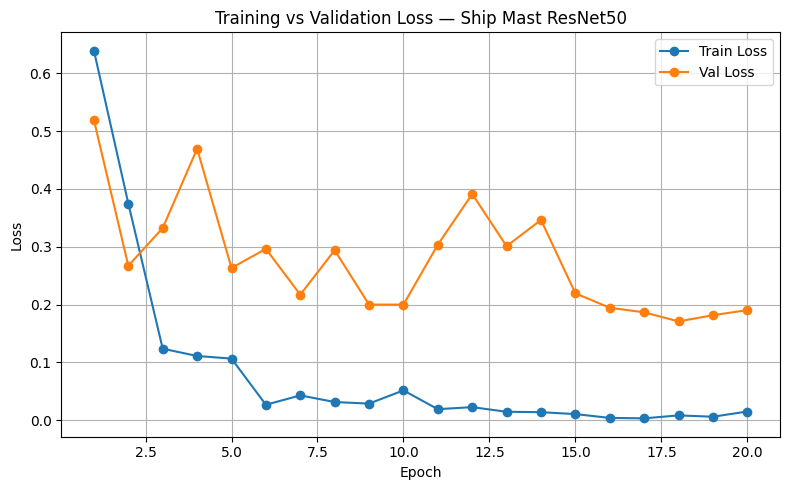

In [22]:
epochs_range = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history['train_loss'], marker='o', label='Train Loss')
plt.plot(epochs_range, history['val_loss'],   marker='o', label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss — Ship Mast ResNet50')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### Loading the Best Model for Evaluation

In [23]:
best_path = os.path.join(save_dir, "ship_mast_best.pth")

model.load_state_dict(torch.load(best_path, map_location=device))
model.eval()
print("Best model loaded from:", best_path)

Best model loaded from: /content/drive/My Drive/new_ship_mast_dataset/checkpoints/ship_mast_best.pth


#### Test Accuracy

In [24]:
def test_accuracy(loader, threshold=0.5):
    model.eval()
    correct = 0
    total   = 0

    with torch.no_grad():
        for img1, img2, label in loader:
            img1  = img1.to(device)
            img2  = img2.to(device)
            label = label.to(device)

            logits = model(img1, img2)
            probs  = torch.sigmoid(logits)
            preds  = (probs > threshold).float()

            correct += (preds == label).sum().item()
            total   += label.size(0)

    return correct / total


acc = test_accuracy(test_loader)
print(f"Test Accuracy (threshold=0.5): {acc * 100:.2f}%")

Test Accuracy (threshold=0.5): 96.64%


#### Threshold vs Accuracy

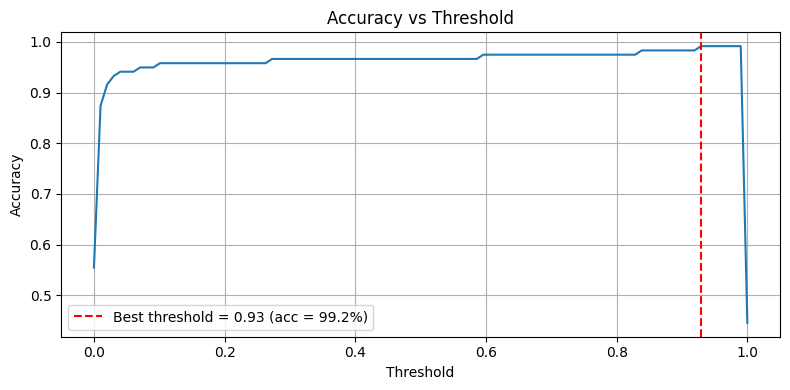

In [25]:
thresholds = np.linspace(0, 1, 100)
accuracies = [test_accuracy(test_loader, t) for t in thresholds]

best_t   = thresholds[np.argmax(accuracies)]
best_acc = max(accuracies)

plt.figure(figsize=(8, 4))
plt.plot(thresholds, accuracies)
plt.axvline(best_t, color='red', linestyle='--',
            label=f'Best threshold = {best_t:.2f} (acc = {best_acc*100:.1f}%)')
plt.xlabel('Threshold')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Threshold')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### FAR / FRR & EER

EER ≈ 0.94%  at threshold = 0.93


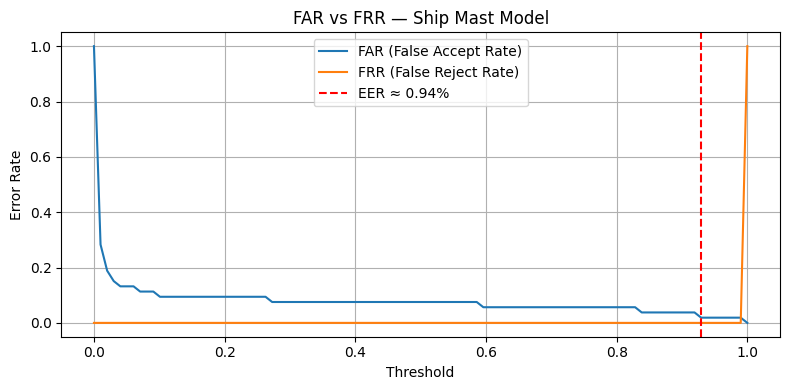

In [28]:
far_list = []
frr_list = []

model.eval()

for t in thresholds:
    TP = FP = TN = FN = 0

    with torch.no_grad():
        for img1, img2, label in test_loader:
            img1  = img1.to(device)
            img2  = img2.to(device)
            label = label.to(device)

            probs = torch.sigmoid(model(img1, img2))
            preds = (probs > t).float()

            TP += ((preds == 1) & (label == 1)).sum().item()
            TN += ((preds == 0) & (label == 0)).sum().item()
            FP += ((preds == 1) & (label == 0)).sum().item()
            FN += ((preds == 0) & (label == 1)).sum().item()

    FAR = FP / (FP + TN + 1e-8)
    FRR = FN / (FN + TP + 1e-8)
    far_list.append(FAR)
    frr_list.append(FRR)

# EER — point where FAR ≈ FRR
eer_idx = np.argmin(np.abs(np.array(far_list) - np.array(frr_list)))
eer     = (far_list[eer_idx] + frr_list[eer_idx]) / 2
print(f"EER ≈ {eer * 100:.2f}%  at threshold = {thresholds[eer_idx]:.2f}")

plt.figure(figsize=(8, 4))
plt.plot(thresholds, far_list, label='FAR (False Accept Rate)')
plt.plot(thresholds, frr_list, label='FRR (False Reject Rate)')
plt.axvline(thresholds[eer_idx], color='red', linestyle='--',
            label=f'EER ≈ {eer*100:.2f}%')
plt.xlabel('Threshold')
plt.ylabel('Error Rate')
plt.title('FAR vs FRR — Ship Mast Model')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### Classification Report & Confusion Matrix

In [29]:
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)


def get_predictions(loader, threshold=0.5):
    model.eval()
    all_labels = []
    all_preds  = []

    with torch.no_grad():
        for img1, img2, label in loader:
            img1 = img1.to(device)
            img2 = img2.to(device)

            probs = torch.sigmoid(model(img1, img2))
            preds = (probs > threshold).float()

            all_labels.extend(label.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    return all_labels, all_preds


y_true, y_pred = get_predictions(test_loader, threshold=best_t)

print(f"Using best threshold: {best_t:.2f}\n")
print("Precision :", precision_score(y_true, y_pred, pos_label=1))
print("Recall    :", recall_score(y_true, y_pred, pos_label=1))
print("F1 Score  :", f1_score(y_true, y_pred, pos_label=1))
print("\nConfusion Matrix")
print(confusion_matrix(y_true, y_pred))
print("\nClassification Report")
print(classification_report(y_true, y_pred,
                             target_names=['Good-Good (0)', 'Good-Damaged (1)']))

Using best threshold: 0.93

Precision : 0.9850746268656716
Recall    : 1.0
F1 Score  : 0.9924812030075187

Confusion Matrix
[[52  1]
 [ 0 66]]

Classification Report
                  precision    recall  f1-score   support

   Good-Good (0)       1.00      0.98      0.99        53
Good-Damaged (1)       0.99      1.00      0.99        66

        accuracy                           0.99       119
       macro avg       0.99      0.99      0.99       119
    weighted avg       0.99      0.99      0.99       119

